In [4]:
print(os.getcwd())

e:\Downloads


In [5]:
import os
import geopandas as gpd
import pandas as pd
print(os.getcwd())

# resources: https://data.sfgov.org/browse?q=Analysis+Neighborhoods&sortBy=relevance&page=1&pageSize=20

neighborhoods = gpd.read_file(r"E:\Downloads\Analysis_Neighborhoods_geo.geojson")
print(neighborhoods.shape)
neighborhoods.head() 

e:\Downloads
(41, 6)


,:id,:version,:created_at,:updated_at,nhood,geometry
0,row-kat6_uieb_3jtd,rv-dbu2~hpud.6yya,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213..."
1,row-z3d4_b3is_mfk7,rv-zi62-zgjg-kwse,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605..."
2,row-xwem-yyxg.b4xp,rv-n2ba~749k.nkaj,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Visitacion Valley,"MULTIPOLYGON (((-122.40385 37.71883, -122.4035..."
3,row-cyst-jf3k~s9cp,rv-emkr.suep.757p,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Twin Peaks,"MULTIPOLYGON (((-122.44695 37.75655, -122.4459..."
4,row-zga5_xbxp_wavz,rv-dhre.4pg3-htj9,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,South of Market,"MULTIPOLYGON (((-122.40371 37.78404, -122.4027..."


Information displayed is not "high level", not very readable. What I really need is the geometry (coordinates) and the nhood (neighborhood).

<Axes: >

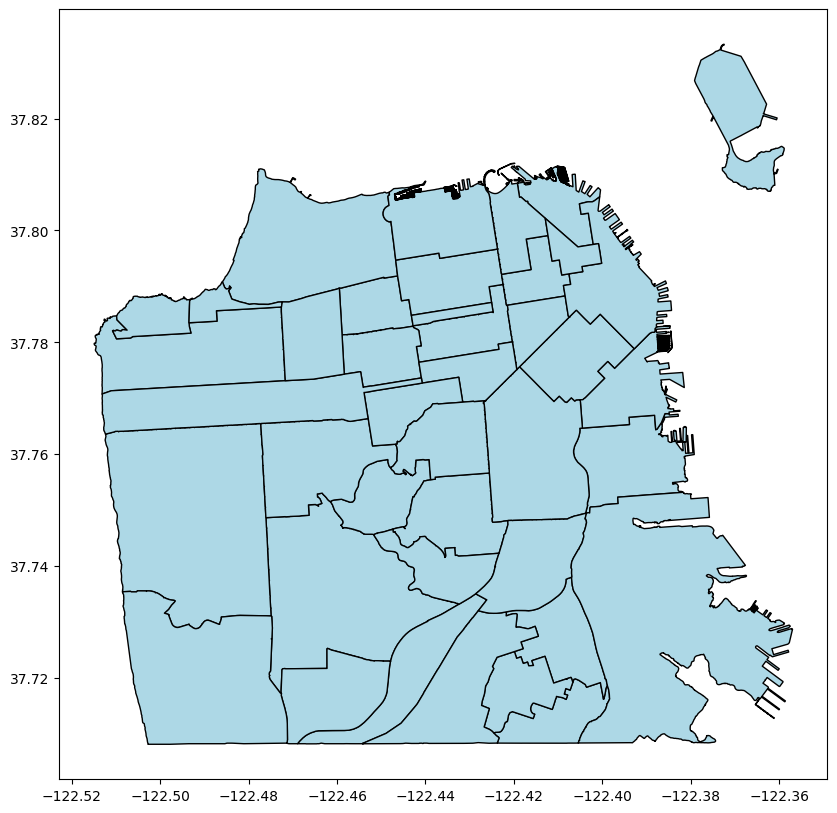

In [6]:
neighborhoods = neighborhoods[["nhood", "geometry"]] # keep only the neighborhood name and geometry columns
neighborhoods.head()

#plotting

neighborhoods.plot(figsize = (10, 10), edgecolor='black', color='lightblue')

This looks nice. Now the next step is to map them to their respective zipcodes.

In [7]:
crosswalk = pd.read_csv(r"E:\Downloads\Analysis_Neighborhoods_to_ZIP_Code_Crosswalk_20260601.csv")
print(crosswalk.shape)

(152, 4)


In [8]:
crosswalk.head()

,nhood,zip_code,data_loaded_at,data_as_of
0,Western Addition,94102,2023/06/23 06:21:48 PM,2023/06/20 08:51:51 PM
1,Western Addition,94109,2023/06/23 06:21:48 PM,2023/06/20 08:51:51 PM
2,Western Addition,94115,2023/06/23 06:21:48 PM,2023/06/20 08:51:51 PM
3,Western Addition,94117,2023/06/23 06:21:48 PM,2023/06/20 08:51:51 PM
4,West of Twin Peaks,94127,2023/06/23 06:21:48 PM,2023/06/20 08:51:51 PM


From here, we can see that there are 152 rows and 4 columns, of those column, the only useful ones are the neighborhoods and the zip code.

In [9]:
crosswalk = crosswalk[["nhood", "zip_code"]] # keep only the neighborhood name and zip code columns
crosswalk.head()

#awesome! we have the neighborhood geometries and the crosswalk to zip codes. We can now merge these two datasets together to get a geospatial dataset with both the neighborhood geometries and the corresponding zip codes.

,nhood,zip_code
0,Western Addition,94102
1,Western Addition,94109
2,Western Addition,94115
3,Western Addition,94117
4,West of Twin Peaks,94127


In [10]:
neighborhoods.head()

,nhood,geometry
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213..."
1,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605..."
2,Visitacion Valley,"MULTIPOLYGON (((-122.40385 37.71883, -122.4035..."
3,Twin Peaks,"MULTIPOLYGON (((-122.44695 37.75655, -122.4459..."
4,South of Market,"MULTIPOLYGON (((-122.40371 37.78404, -122.4027..."


In [11]:
neighborhoods_zips = neighborhoods.merge(crosswalk, on="nhood", how="left")

print(neighborhoods_zips.shape)
neighborhoods_zips.head(10)

(152, 3)


,nhood,geometry,zip_code
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127
5,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94131
6,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94132
7,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94112
8,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94116
9,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94122


Key being joined on for both tables is the "nhood" column, as both data sets contain the neighboroods.

In [12]:
neighborhoods_zips.shape

(152, 3)

In [13]:
print("Number of unique neighborhoods: {}".format(neighborhoods_zips['nhood'].nunique()))
print("Number of unique zip codes: {}".format(neighborhoods_zips['zip_code'].nunique()))
# ZIP codes were designed for mail delivery routing, not to match neighborhood boundaries, so it's common for a single 
# neighborhood to be associated with multiple ZIP codes, and for a single ZIP code to cover multiple neighborhoods. 
# This is why we see more unique ZIP codes than neighborhoods in our merged dataset.

Number of unique neighborhoods: 41
Number of unique zip codes: 27


In [14]:
neighborhoods_zips['centroid'] = neighborhoods_zips.geometry.centroid

neighborhoods_zips.head()

C:\Users\icsti\AppData\Local\Temp\ipykernel_16700\1844032445.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  neighborhoods_zips['centroid'] = neighborhoods_zips.geometry.centroid


,nhood,geometry,zip_code,centroid
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,POINT (-122.43063 37.78183)
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,POINT (-122.43063 37.78183)
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,POINT (-122.43063 37.78183)
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,POINT (-122.43063 37.78183)
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,POINT (-122.45994 37.73518)


In [15]:
# Reproject to California Albers (flat, accurate for CA)
proj = neighborhoods_zips.to_crs(epsg=3310)

# Compute accurate centroids, then convert back to lat/lng
centroids = proj.geometry.centroid.to_crs(epsg=4326)

# Store as lat/lng columns (what Google Maps API will need)
neighborhoods_zips['centroid'] = centroids
neighborhoods_zips['lat'] = centroids.y
neighborhoods_zips['lng'] = centroids.x

neighborhoods_zips[['nhood', 'zip_code', 'lat', 'lng']].head()

,nhood,zip_code,lat,lng
0,Western Addition,94102,37.781831,-122.430630
1,Western Addition,94109,37.781831,-122.430630
2,Western Addition,94115,37.781831,-122.430630
3,Western Addition,94117,37.781831,-122.430630
4,West of Twin Peaks,94127,37.735181,-122.459937


In [16]:
neighborhoods_zips.shape

(152, 6)

In [17]:
neighborhoods_zips

,nhood,geometry,zip_code,centroid,lat,lng
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,POINT (-122.43063 37.78183),37.781831,-122.430630
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,POINT (-122.43063 37.78183),37.781831,-122.430630
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,POINT (-122.43063 37.78183),37.781831,-122.430630
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,POINT (-122.43063 37.78183),37.781831,-122.430630
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,POINT (-122.45994 37.73518),37.735181,-122.459937
...,...,...,...,...,...,...
147,Bernal Heights,"MULTIPOLYGON (((-122.40361 37.74934, -122.4037...",94112,POINT (-122.41566 37.74036),37.740364,-122.415664
148,Bayview Hunters Point,"MULTIPOLYGON (((-122.38158 37.75307, -122.3815...",94124,POINT (-122.38602 37.73089),37.730888,-122.386016
149,Bayview Hunters Point,"MULTIPOLYGON (((-122.38158 37.75307, -122.3815...",94134,POINT (-122.38602 37.73089),37.730888,-122.386016
150,Bayview Hunters Point,"MULTIPOLYGON (((-122.38158 37.75307, -122.3815...",94107,POINT (-122.38602 37.73089),37.730888,-122.386016


In [18]:
neighborhoods_zips = neighborhoods_zips.drop(columns=['centroid'])
# centroid column is redundant now that we have lat/lng columns, and it can cause issues when exporting to CSV since it's a geometry type.

neighborhoods_zips

,nhood,geometry,zip_code,lat,lng
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,37.781831,-122.430630
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,37.781831,-122.430630
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,37.781831,-122.430630
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937
...,...,...,...,...,...
147,Bernal Heights,"MULTIPOLYGON (((-122.40361 37.74934, -122.4037...",94112,37.740364,-122.415664
148,Bayview Hunters Point,"MULTIPOLYGON (((-122.38158 37.75307, -122.3815...",94124,37.730888,-122.386016
149,Bayview Hunters Point,"MULTIPOLYGON (((-122.38158 37.75307, -122.3815...",94134,37.730888,-122.386016
150,Bayview Hunters Point,"MULTIPOLYGON (((-122.38158 37.75307, -122.3815...",94107,37.730888,-122.386016


nhood — The neighborhood name (e.g. "Western Addition", "Bayview Hunters Point"). This is the primary identifier for each neighborhood.

geometry — The full polygon boundary of the neighborhood. This is every coordinate pair that traces the exact outline/border on a map. This is what gets drawn when you call .plot().

zip_code — A ZIP code that intersects with this neighborhood. One neighborhood can have multiple rows here because it can span multiple ZIP codes.

centroid — The geographic center of the neighborhood stored as a geometry POINT object. This is a geopandas-specific format.

lat — Latitude of the centroid as a plain decimal number (WGS84). This is what APIs like Google Maps expect. (Y = Latitude)

lng — Longitude of the centroid as a plain decimal number (WGS84). Same ; plain number for API use. (X = Longitude)

** side note **
WGS84 is basically the standard coordinate system used by GPS.

* So Far !!

We have neighborhood, centroids, coordinates, and zipcodes of all neighborhoods in San Francisco:

Some metrics we should look at include: 

* Commute Time - (i.e: car ride/ public transport from XYZ school to centroid)
* Availablity - count of active rental listings in neighborhood
* Average rent - median price rather than mean (avoiding skewed metrics) for given neighborhood




In [19]:
!pip install openrouteservice

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [20]:

import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "openrouteservice", "python-dotenv"])

CompletedProcess(args=['e:\\Downloads\\python.exe', '-m', 'pip', 'install', 'openrouteservice', 'python-dotenv'], returncode=0)

In [21]:
from dotenv import load_dotenv
import os

load_dotenv()
ORS_API_KEY = os.getenv("ORS_API_KEY")
print("Key loaded:", ORS_API_KEY is not None)

Key loaded: True


In [22]:
import openrouteservice

client = openrouteservice.Client(key=ORS_API_KEY)

# USFCA main campus [lng, lat] — ORS takes longitude FIRST, then latitude
usfca = [-122.4511, 37.7743]

# Western Addition centroid [lng, lat]
western_addition = [-122.430630, 37.781831]

result = client.directions(
    coordinates=[western_addition, usfca],
    profile='driving-car',
    format='json'
)

# Testing with one neighborhood first to make sure we can get the API working, then we can loop through all the neighborhoods later.
seconds = result['routes'][0]['summary']['duration']
print(f"Driving time from Western Addition to USFCA: {seconds/60:.1f} minutes")

Driving time from Western Addition to USFCA: 5.3 minutes


In [23]:
import time

# Get unique neighborhoods with their centroids
unique_hoods = neighborhoods_zips.drop_duplicates(subset='nhood')[['nhood', 'lat', 'lng']].reset_index(drop=True)

# USFCA coordinates
usfca = [-122.4511, 37.7743]

# Loop through each neighborhood and get driving time
results = []

for _, row in unique_hoods.iterrows():
    origin = [row['lng'], row['lat']]
    try:
        result = client.directions(
            coordinates=[origin, usfca],
            profile='driving-car',
            format='json'
        )
        duration_min = result['routes'][0]['summary']['duration'] / 60
        results.append({'nhood': row['nhood'], 'drive_min_usfca': round(duration_min, 1)})
    except Exception as e:
        results.append({'nhood': row['nhood'], 'drive_min_usfca': None})
        print(f"Error for {row['nhood']}: {e}")
    time.sleep(0.5)  

commute_df = pd.DataFrame(results)
commute_df.sort_values('drive_min_usfca')

Error for Lakeshore: 404 ({'error': {'code': 2010, 'message': 'Could not find routable point within a radius of 350.0 meters of specified coordinate 0: -122.4903510 37.7202089.'}, 'info': {'engine': {'build_date': '2026-04-20T10:23:42Z', 'graph_version': '4', 'graph_date': '2026-05-15T15:29:58Z', 'osm_date': '2026-04-26T23:59:57Z', 'version': '9.9.0'}, 'timestamp': 1780523446840}})


e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


,nhood,drive_min_usfca
17,Lone Mountain/USF,2.7
31,Haight Ashbury,2.8
33,Inner Richmond,5.1
0,Western Addition,5.3
28,Japantown,5.4
30,Hayes Valley,5.6
38,Castro/Upper Market,5.7
6,Presidio Heights,6.0
29,Inner Sunset,6.7
10,Pacific Heights,7.3


In [24]:
neighborhoods_zips = neighborhoods_zips.merge(commute_df, on='nhood', how='left')
neighborhoods_zips[['nhood', 'zip_code', 'lat', 'lng', 'drive_min_usfca']].drop_duplicates(subset='nhood')

,nhood,zip_code,lat,lng,drive_min_usfca
0,Western Addition,94102,37.781831,-122.430630,5.3
4,West of Twin Peaks,94127,37.735181,-122.459937,13.4
10,Visitacion Valley,94124,37.712867,-122.410105,19.6
12,Twin Peaks,94127,37.752113,-122.449797,8.7
16,South of Market,94102,37.777249,-122.405928,11.0
21,Treasure Island,94130,37.820655,-122.369539,20.6
22,Presidio Heights,94115,37.786313,-122.451658,6.0
25,Presidio,94115,37.797377,-122.466370,10.7
30,Potrero Hill,94124,37.758872,-122.393602,14.3
36,Portola,94124,37.726792,-122.408993,16.6


In [25]:
results_walk = []

for _, row in unique_hoods.iterrows():
    origin = [row['lng'], row['lat']]
    try:
        result = client.directions(
            coordinates=[origin, usfca],
            profile='foot-walking',
            format='json'
        )
        duration_min = result['routes'][0]['summary']['duration'] / 60
        results_walk.append({'nhood': row['nhood'], 'walk_min_usfca': round(duration_min, 1)})
    except Exception as e:
        results_walk.append({'nhood': row['nhood'], 'walk_min_usfca': None})
        print(f"Error for {row['nhood']}: {e}")
    time.sleep(0.5)

walk_df = pd.DataFrame(results_walk)
walk_df.sort_values('walk_min_usfca')

e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


,nhood,walk_min_usfca
17,Lone Mountain/USF,6.5
31,Haight Ashbury,13.9
6,Presidio Heights,20.8
33,Inner Richmond,24.1
30,Hayes Valley,25.9
0,Western Addition,29.1
38,Castro/Upper Market,30.1
28,Japantown,30.9
29,Inner Sunset,31.9
32,Golden Gate Park,37.7


In [26]:
results_cycle = []

for _, row in unique_hoods.iterrows():
    origin = [row['lng'], row['lat']]
    try:
        result = client.directions(
            coordinates=[origin, usfca],
            profile='cycling-regular',
            format='json'
        )
        duration_min = result['routes'][0]['summary']['duration'] / 60
        results_cycle.append({'nhood': row['nhood'], 'cycle_min_usfca': round(duration_min, 1)})
    except Exception as e:
        results_cycle.append({'nhood': row['nhood'], 'cycle_min_usfca': None})
        print(f"Error for {row['nhood']}: {e}")
    time.sleep(0.5)

cycle_df = pd.DataFrame(results_cycle)
cycle_df.sort_values('cycle_min_usfca')

e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


,nhood,cycle_min_usfca
17,Lone Mountain/USF,2.1
31,Haight Ashbury,4.7
6,Presidio Heights,6.2
33,Inner Richmond,7.0
30,Hayes Valley,8.1
38,Castro/Upper Market,8.5
0,Western Addition,8.7
28,Japantown,8.8
29,Inner Sunset,9.3
10,Pacific Heights,10.8


In [27]:
neighborhoods_zips = neighborhoods_zips.merge(walk_df, on='nhood', how='left')
neighborhoods_zips = neighborhoods_zips.merge(cycle_df, on='nhood', how='left')

# Quick view of just the commute columns
neighborhoods_zips[['nhood', 'drive_min_usfca', 'walk_min_usfca', 'cycle_min_usfca']].drop_duplicates(subset='nhood').sort_values('drive_min_usfca')

,nhood,drive_min_usfca,walk_min_usfca,cycle_min_usfca
62,Lone Mountain/USF,2.7,6.5,2.1
109,Haight Ashbury,2.8,13.9,4.7
116,Inner Richmond,5.1,24.1,7.0
0,Western Addition,5.3,29.1,8.7
98,Japantown,5.4,30.9,8.8
105,Hayes Valley,5.6,25.9,8.1
138,Castro/Upper Market,5.7,30.1,8.5
22,Presidio Heights,6.0,20.8,6.2
100,Inner Sunset,6.7,31.9,9.3
40,Pacific Heights,7.3,38.5,10.8


In [28]:
# Add SFSU data
sfsu = [-122.4801, 37.7245]

# --- DRIVING ---
results_drive_sfsu = []
for _, row in unique_hoods.iterrows():
    origin = [row['lng'], row['lat']]
    try:
        result = client.directions(
            coordinates=[origin, sfsu],
            profile='driving-car',
            format='json'
        )
        duration_min = result['routes'][0]['summary']['duration'] / 60
        results_drive_sfsu.append({'nhood': row['nhood'], 'drive_min_sfsu': round(duration_min, 1)})
    except Exception as e:
        results_drive_sfsu.append({'nhood': row['nhood'], 'drive_min_sfsu': None})
        print(f"Error for {row['nhood']}: {e}")
    time.sleep(0.5)

Error for Lakeshore: 404 ({'error': {'code': 2010, 'message': 'Could not find routable point within a radius of 350.0 meters of specified coordinate 0: -122.4903510 37.7202089.'}, 'info': {'engine': {'build_date': '2026-04-20T10:23:42Z', 'graph_version': '4', 'graph_date': '2026-05-15T15:29:58Z', 'osm_date': '2026-04-26T23:59:57Z', 'version': '9.9.0'}, 'timestamp': 1780523674552}})


e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


In [29]:
# --- WALKING ---
results_walk_sfsu = []
for _, row in unique_hoods.iterrows():
    origin = [row['lng'], row['lat']]
    try:
        result = client.directions(
            coordinates=[origin, sfsu],
            profile='foot-walking',
            format='json'
        )
        duration_min = result['routes'][0]['summary']['duration'] / 60
        results_walk_sfsu.append({'nhood': row['nhood'], 'walk_min_sfsu': round(duration_min, 1)})
    except Exception as e:
        results_walk_sfsu.append({'nhood': row['nhood'], 'walk_min_sfsu': None})
        print(f"Error for {row['nhood']}: {e}")
    time.sleep(0.5)

e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


In [30]:
# --- CYCLING ---
results_cycle_sfsu = []
for _, row in unique_hoods.iterrows():
    origin = [row['lng'], row['lat']]
    try:
        result = client.directions(
            coordinates=[origin, sfsu],
            profile='cycling-regular',
            format='json'
        )
        duration_min = result['routes'][0]['summary']['duration'] / 60
        results_cycle_sfsu.append({'nhood': row['nhood'], 'cycle_min_sfsu': round(duration_min, 1)})
    except Exception as e:
        results_cycle_sfsu.append({'nhood': row['nhood'], 'cycle_min_sfsu': None})
        print(f"Error for {row['nhood']}: {e}")
    time.sleep(0.5)


e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


In [31]:
# --- MERGE ---
drive_sfsu_df = pd.DataFrame(results_drive_sfsu)
walk_sfsu_df = pd.DataFrame(results_walk_sfsu)
cycle_sfsu_df = pd.DataFrame(results_cycle_sfsu)

neighborhoods_zips = neighborhoods_zips.merge(drive_sfsu_df, on='nhood', how='left')
neighborhoods_zips = neighborhoods_zips.merge(walk_sfsu_df, on='nhood', how='left')
neighborhoods_zips = neighborhoods_zips.merge(cycle_sfsu_df, on='nhood', how='left')

# Preview
neighborhoods_zips[['nhood', 'drive_min_sfsu', 'walk_min_sfsu', 'cycle_min_sfsu']].drop_duplicates(subset='nhood').sort_values('drive_min_sfsu')

,nhood,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu
53,Oceanview/Merced/Ingleside,8.9,32.6,11.1
50,Sunset/Parkside,9.4,39.6,11.8
4,West of Twin Peaks,10.2,39.2,12.5
46,Outer Mission,11.8,49.3,15.2
100,Inner Sunset,12.6,61.3,18.8
112,Golden Gate Park,13.6,72.3,21.6
12,Twin Peaks,14.6,62.6,19.1
131,Excelsior,14.6,63.0,18.9
59,Noe Valley,14.9,74.5,21.7
119,Glen Park,15.1,69.7,21.1


In [32]:
neighborhoods_zips

,nhood,geometry,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,12.5
...,...,...,...,...,...,...,...,...,...,...,...
147,Bernal Heights,"MULTIPOLYGON (((-122.40361 37.74934, -122.4037...",94112,37.740364,-122.415664,13.7,76.7,23.2,15.7,85.6,25.5
148,Bayview Hunters Point,"MULTIPOLYGON (((-122.38158 37.75307, -122.3815...",94124,37.730888,-122.386016,18.4,117.7,33.4,20.9,120.9,34.8
149,Bayview Hunters Point,"MULTIPOLYGON (((-122.38158 37.75307, -122.3815...",94134,37.730888,-122.386016,18.4,117.7,33.4,20.9,120.9,34.8
150,Bayview Hunters Point,"MULTIPOLYGON (((-122.38158 37.75307, -122.3815...",94107,37.730888,-122.386016,18.4,117.7,33.4,20.9,120.9,34.8


In [33]:
# Time to append UCSF

ucsf_parnassus = [-122.4580, 37.7631]
ucsf_missionbay = [-122.3926, 37.7687]

for school_name, school_coords in [('ucsf_parnassus', ucsf_parnassus), ('ucsf_missionbay', ucsf_missionbay)]:
    for mode, profile in [('drive', 'driving-car'), ('walk', 'foot-walking'), ('cycle', 'cycling-regular')]:
        results = []
        for _, row in unique_hoods.iterrows():
            origin = [row['lng'], row['lat']]
            try:
                result = client.directions(
                    coordinates=[origin, school_coords],
                    profile=profile,
                    format='json'
                )
                duration_min = result['routes'][0]['summary']['duration'] / 60
                results.append({'nhood': row['nhood'], f'{mode}_min_{school_name}': round(duration_min, 1)})
            except Exception as e:
                results.append({'nhood': row['nhood'], f'{mode}_min_{school_name}': None})
                print(f"Error for {row['nhood']} ({school_name}, {mode}): {e}")
            time.sleep(0.5)
        
        temp_df = pd.DataFrame(results)
        neighborhoods_zips = neighborhoods_zips.merge(temp_df, on='nhood', how='left')
        print(f"Done: {mode} to {school_name}")

# Preview all commute columns
commute_cols = ['nhood'] + [c for c in neighborhoods_zips.columns if 'min' in c]
neighborhoods_zips[commute_cols].drop_duplicates(subset='nhood').sort_values('drive_min_ucsf_parnassus')

e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


Error for Lakeshore (ucsf_parnassus, drive): 404 ({'error': {'code': 2010, 'message': 'Could not find routable point within a radius of 350.0 meters of specified coordinate 0: -122.4903510 37.7202089.'}, 'info': {'engine': {'build_date': '2026-04-20T10:23:42Z', 'graph_version': '4', 'graph_date': '2026-05-15T15:29:58Z', 'osm_date': '2026-04-26T23:59:57Z', 'version': '9.9.0'}, 'timestamp': 1780523950402}})
Done: drive to ucsf_parnassus


e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


Done: walk to ucsf_parnassus


e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


...

e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


Done: walk to ucsf_missionbay


e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
e:\Downloads\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 5th time.


Done: cycle to ucsf_missionbay


,nhood,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu,drive_min_ucsf_parnassus,walk_min_ucsf_parnassus,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay
100,Inner Sunset,6.7,31.9,9.3,12.6,61.3,18.8,2.2,12.4,3.8,16.9,90.9,26.3
109,Haight Ashbury,2.8,13.9,4.7,16.8,88.3,28.0,2.7,18.7,6.2,13.5,62.6,19.0
138,Castro/Upper Market,5.7,30.1,8.5,17.1,87.3,26.1,5.0,29.5,9.3,10.6,52.3,15.3
112,Golden Gate Park,8.1,37.7,11.1,13.6,72.3,21.6,6.0,35.5,10.1,19.8,104.7,31.5
62,Lone Mountain/USF,2.7,6.5,2.1,19.9,98.9,32.5,6.1,28.0,8.5,14.6,71.8,22.5
12,Twin Peaks,8.7,38.7,11.2,14.6,62.6,19.1,6.6,31.6,10.0,15.8,84.3,24.7
59,Noe Valley,8.2,48.5,13.7,14.9,74.5,21.7,7.0,45.2,13.5,12.4,66.8,20.4
105,Hayes Valley,5.6,25.9,8.1,21.5,108.3,32.5,7.3,40.4,12.7,10.1,47.8,13.8
0,Western Addition,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3
116,Inner Richmond,5.1,24.1,7.0,18.1,92.6,29.5,8.1,31.1,10.5,18.1,94.1,29.3


Sources for driving, walking, and cycling, we'll add commute time later (most important as many students I would imagine depend on public transport to get to their campuses)
https://openrouteservice.org/    --> walking, cyclying, driving times
https://511.org/ --> public transport

In [34]:
neighborhoods_zips.head()

,nhood,geometry,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu,drive_min_ucsf_parnassus,walk_min_ucsf_parnassus,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,12.5,8.9,49.8,14.4,11.2,106.3,30.7


In [35]:
commute_cols = ['nhood'] + [c for c in neighborhoods_zips.columns if 'min' in c]
neighborhoods_zips[commute_cols].drop_duplicates(subset='nhood')

,nhood,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu,drive_min_ucsf_parnassus,walk_min_ucsf_parnassus,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay
0,Western Addition,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3
4,West of Twin Peaks,13.4,69.3,19.9,10.2,39.2,12.5,8.9,49.8,14.4,11.2,106.3,30.7
10,Visitacion Valley,19.6,115.5,34.2,18.8,92.5,27.9,20.6,113.2,32.4,11.7,94.4,28.2
12,Twin Peaks,8.7,38.7,11.2,14.6,62.6,19.1,6.6,31.6,10.0,15.8,84.3,24.7
16,South of Market,11.0,53.1,17.6,19.4,127.9,38.7,12.9,66.4,20.3,6.7,23.8,9.0
21,Treasure Island,20.6,109.5,118.9,29.5,187.2,137.9,22.4,124.8,121.6,16.4,80.1,98.5
22,Presidio Heights,6.0,20.8,6.2,21.1,110.6,35.6,8.9,39.7,11.9,15.5,82.4,26.3
25,Presidio,10.7,42.8,13.6,25.4,118.6,40.0,13.6,55.8,18.6,21.3,110.1,35.5
30,Potrero Hill,14.3,80.2,23.7,16.2,127.0,37.4,13.7,83.1,23.9,3.6,17.4,5.8
36,Portola,16.6,97.8,29.1,18.1,92.0,27.2,17.6,94.5,27.3,11.9,73.5,21.9


## Known Limitation
* Transit commute times (Muni/BART) not yet included; 511 SF Bay API was unavailable at time of writing. 
* To add: request token at 511.org/open-data/token, then query transit times using the same loop structure.

In [36]:
zillow = pd.read_csv(r"E:\Downloads\zillow.csv")
zillow.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2015-01-31,...,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,1382.485889,...,1736.951964,1745.514554,1741.294231,1732.244497,1719.408221,1715.273167,1695.842131,1683.702020,1664.191684,1660.034577
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2133.843943,2202.557545,2132.424394,2119.333333
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,1247.519342,...,1832.627905,1824.688732,1816.539786,1815.630208,1805.124318,1814.680790,1803.978163,1807.518808,1789.213615,1784.279693
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2725.504622,2750.000000
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,1099.478752,...,1586.090104,1591.663870,1590.368942,1585.461700,1576.546145,1570.756272,1571.819532,1565.203405,1557.190599,1547.429218


In [37]:
zillow.shape

(8316, 145)

In [38]:
# Get our SF zip codes
sf_zips = neighborhoods_zips['zip_code'].unique().tolist()

# Filter Zillow to SF only
zillow_sf = zillow[zillow['RegionName'].isin(sf_zips)].copy()

print(f"Found {len(zillow_sf)} matching SF ZIP codes")

# Keep only ZIP and the most recent month
zillow_sf = zillow_sf[['RegionName', '2026-04-30']].rename(columns={
    'RegionName': 'zip_code',
    '2026-04-30': 'median_rent'
})

zillow_sf

Found 24 matching SF ZIP codes


,zip_code,median_rent
69,94112,3505.841667
207,94110,3938.619987
458,94122,3593.939394
634,94109,3364.630688
1524,94116,3042.194444
1593,94117,3999.739881
1643,94118,4015.583333
1730,94121,3689.027778
1932,94134,4012.527778
2354,94124,4244.444444


In [39]:
# 24/27 zip codes found, 3 missing. Let's see which ones are missing.
sf_zips_set = set(sf_zips)
zillow_zips_set = set(zillow_sf['zip_code'].tolist())
missing = sf_zips_set - zillow_zips_set
print("Missing ZIP codes:", missing)

Missing ZIP codes: {94104, 94130, 94111}


* 94104 — Financial District core, almost entirely office buildings, virtually no residential rentals
* 94130 — Treasure Island, isolated island with very limited housing stock
* 94111 — Embarcadero area, mostly commercial waterfront

In [40]:
neighborhoods_zips = neighborhoods_zips.merge(zillow_sf, on='zip_code', how='left')

# Check it
neighborhoods_zips[['nhood', 'zip_code', 'median_rent']].drop_duplicates(subset='nhood').sort_values('median_rent', ascending=False)

,nhood,zip_code,median_rent
4,West of Twin Peaks,94127,5566.666667
12,Twin Peaks,94127,5566.666667
119,Glen Park,94127,5566.666667
53,Oceanview/Merced/Ingleside,94127,5566.666667
74,Mission Bay,94158,5005.854487
109,Haight Ashbury,94114,4756.661616
123,Financial District/South Beach,94133,4591.115476
86,Russian Hill,94133,4591.115476
134,Chinatown,94133,4591.115476
56,North Beach,94133,4591.115476


## Limitation: Rent data is ZIP-level, not neighborhood-level
Zillow ZORI data is only available at ZIP code granularity. Neighborhoods sharing 

a ZIP code (e.g. 94127 covers West of Twin Peaks, Twin Peaks, Glen Park, and 

Oceanview/Merced/Ingleside) will show identical median rent values.

For higher resolution rent data, a listings API like RentCast would be needed.

In [41]:
neighborhoods_zips.head()

,nhood,geometry,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu,drive_min_ucsf_parnassus,walk_min_ucsf_parnassus,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay,median_rent
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3237.048333
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3364.630688
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,4016.927583
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3999.739881
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,12.5,8.9,49.8,14.4,11.2,106.3,30.7,5566.666667


In [42]:
neighborhoods_zips = neighborhoods_zips.rename(columns={'median_rent': 'median_rent_by_zip'})
neighborhoods_zips.head()

,nhood,geometry,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu,drive_min_ucsf_parnassus,walk_min_ucsf_parnassus,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay,median_rent_by_zip
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3237.048333
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3364.630688
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,4016.927583
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3999.739881
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,12.5,8.9,49.8,14.4,11.2,106.3,30.7,5566.666667


There are 41 neighborhoods in SF, and 27 zip codes, of which ~23 I believe from earlier are actually mergable as explained in earlier mark down cell.

But earlier in the plot, it was divided by neighborhood, so for now we'll just rename the column to be explictly be divided by the zip codes.

We're gonna look for one that is divided by neighborhoods to reduce this problem.

https://data.sfgov.org/Geographic-Locations-and-Boundaries/Analysis-Neighborhoods-2020-census-tracts-assigned/sevw-6tgi/about_data

This actually will give us what we need to divide the median rent per 41 neighborhoods in SF

* Using geoid as a key identifier for joins, we will use API from US gov to join them to get an accurate median rent per neighborhood:

https://www.census.gov/data/developers.html

In [43]:
datasf = pd.read_csv(r"E:\Downloads\datasf.csv")    
datasf.head()

,the_geom,object_id,state_fp,county_fp,tractce,name,neighborhoods_analysis_boundaries,data_loaded_at,sup_dist_2012,sup_dist_2022,data_as_of,geoid
0,MULTIPOLYGON (((-122.37276211607421 37.7455051...,242,6,75,980900,9809.00,Bayview Hunters Point,2022 Jul 08 02:12:00 PM,10,10,2022 Jul 08 09:09:48 PM,6075980900
1,MULTIPOLYGON (((-122.36519199065519 37.7337298...,241,6,75,980600,9806.00,Bayview Hunters Point,2022 Jul 08 02:12:00 PM,10,10,2022 Jul 08 09:09:48 PM,6075980600
2,MULTIPOLYGON (((-122.40666500014143 37.7192149...,240,6,75,980501,9805.01,McLaren Park,2022 Jul 08 02:12:00 PM,10,10,2022 Jul 08 09:09:48 PM,6075980501
3,MULTIPOLYGON (((-123.00359900126116 37.6932479...,239,6,75,980401,9804.01,The Farallones,2022 Jul 08 02:12:00 PM,1,4,2022 Jul 08 09:09:48 PM,6075980401
4,MULTIPOLYGON (((-122.38528200051307 37.7402399...,226,6,75,61200,612.00,Bayview Hunters Point,2022 Jul 08 02:12:00 PM,10,10,2022 Jul 08 09:09:48 PM,6075061200


In [44]:
# Save checkpoint after API calls
neighborhoods_zips.to_pickle("neighborhoods_zips_checkpoint.pkl")

In [48]:
import pandas as pd
import geopandas as gpd

neighborhoods_zips = pd.read_pickle(r"E:\Downloads\SF Colleges Housing\neighborhoods_zips_checkpoint.pkl")
print(neighborhoods_zips.shape)

(152, 18)


In [46]:
neighborhoods_zips.to_pickle(r"E:\Downloads\SF Colleges Housing\neighborhoods_zips_checkpoint.pkl")
print("Saved!")

Saved!


In [ ]:
# Run these after restarts

# Run these after restart

import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "openrouteservice", "python-dotenv", "geopandas", "pandas", "matplotlib"])

import geopandas as gpd
import pandas as pd
import os
import time
from dotenv import load_dotenv
import openrouteservice

load_dotenv()
ORS_API_KEY = os.getenv("ORS_API_KEY")

neighborhoods_zips = pd.read_pickle(r"E:\Downloads\SF Colleges Housing\neighborhoods_zips_checkpoint.pkl")

client = openrouteservice.Client(key=ORS_API_KEY)

unique_hoods = neighborhoods_zips.drop_duplicates(subset='nhood')[['nhood', 'lat', 'lng']].reset_index(drop=True)

print("All set! neighborhoods_zips shape:", neighborhoods_zips.shape)
print("Unique neighborhoods:", len(unique_hoods))
print("ORS client ready:", ORS_API_KEY is not None)

In [49]:
neighborhoods_zips.head()

,nhood,geometry,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu,drive_min_ucsf_parnassus,walk_min_ucsf_parnassus,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay,median_rent_by_zip
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3237.048333
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3364.630688
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,4016.927583
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3999.739881
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,12.5,8.9,49.8,14.4,11.2,106.3,30.7,5566.666667


# To do's
* add commute times via public transport
* add median rent $ by neighborhood

In [61]:
from dotenv import load_dotenv
import os

load_dotenv(r"E:\Downloads\SF Colleges Housing\.env")

ORS_API_KEY = os.getenv("ORS_API_KEY")
TRANSIT_511_KEY = os.getenv("TRANSIT_511_KEY")
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")

print("ORS key ready:", ORS_API_KEY is not None)
print("511 key ready:", TRANSIT_511_KEY is not None)
print("Census key ready:", CENSUS_API_KEY is not None)

ORS key ready: True
511 key ready: True
Census key ready: True


In [64]:
# Reload the census tract → neighborhood crosswalk
datasf = pd.read_csv(r"E:\Downloads\datasf.csv")

# Keep only the two columns we need and drop The Farallones (islands 30 miles offshore, not relevant)
tract_hood = datasf[['geoid', 'neighborhoods_analysis_boundaries']].copy()
tract_hood = tract_hood[tract_hood['neighborhoods_analysis_boundaries'] != 'The Farallones']
tract_hood.columns = ['geoid', 'nhood']

print(tract_hood.shape)
tract_hood.head()

(241, 2)


,geoid,nhood
0,6075980900,Bayview Hunters Point
1,6075980600,Bayview Hunters Point
2,6075980501,McLaren Park
4,6075061200,Bayview Hunters Point
5,6075061102,Chinatown


In [65]:
# Pull median gross rent by census tract for SF from Census ACS API
import requests

# B25064_001E = median gross rent variable in ACS
# 06 = California state FIPS, 075 = SF county FIPS
url = "https://api.census.gov/data/2023/acs/acs5"
params = {
    "get": "GEO_ID,B25064_001E",
    "for": "tract:*",
    "in": "state:06 county:075",
    "key": CENSUS_API_KEY
}

response = requests.get(url, params=params)
census_data = response.json()

# Convert to dataframe
census_df = pd.DataFrame(census_data[1:], columns=census_data[0])
census_df = census_df.rename(columns={"B25064_001E": "median_rent_neighborhood", "GEO_ID": "geoid"})
census_df['median_rent_neighborhood'] = pd.to_numeric(census_df['median_rent_neighborhood'], errors='coerce')
census_df['geoid'] = census_df['geoid'].str.replace("1400000US", "")

print(census_df.shape)
census_df.head()

(244, 5)


,geoid,median_rent_neighborhood,state,county,tract
0,06075010101,2325,06,075,010101
1,06075010102,-666666666,06,075,010102
2,06075010201,3118,06,075,010201
3,06075010202,3037,06,075,010202
4,06075010300,2898,06,075,010300


In [79]:
tract_rent = tract_hood.merge(census_df[['geoid', 'median_rent_neighborhood']], on='geoid', how='left')

neighborhood_rent = tract_rent.groupby('nhood')['median_rent_neighborhood'].median().reset_index()
neighborhood_rent.columns = ['nhood', 'median_rent_neighborhood']
neighborhood_rent = neighborhood_rent.sort_values('median_rent_neighborhood', ascending=False)

print(neighborhood_rent.shape)
neighborhood_rent

(41, 2)


,nhood,median_rent_neighborhood
29,Presidio,3501.0
28,Potrero Hill,3501.0
39,West of Twin Peaks,3410.0
16,Marina,3371.0
5,Financial District/South Beach,3316.5
19,Mission Bay,3311.0
32,Seacliff,3292.0
21,Noe Valley,3196.0
11,Inner Sunset,3069.0
31,Russian Hill,3037.0


In [80]:
#merge via geoid as key
neighborhoods_zips = neighborhoods_zips.merge(neighborhood_rent, on='nhood', how='left')

# Quick check
neighborhoods_zips[['nhood', 'median_rent_by_zip', 'median_rent_neighborhood']].drop_duplicates(subset='nhood').sort_values('median_rent_neighborhood', ascending=False)

,nhood,median_rent_by_zip,median_rent_neighborhood
30,Potrero Hill,4244.444444,3501.0
25,Presidio,4016.927583,3501.0
4,West of Twin Peaks,5566.666667,3410.0
89,Marina,3364.630688,3371.0
123,Financial District/South Beach,4591.115476,3316.5
74,Mission Bay,5005.854487,3311.0
67,Seacliff,4015.583333,3292.0
59,Noe Valley,4083.801587,3196.0
100,Inner Sunset,4083.801587,3069.0
86,Russian Hill,4591.115476,3037.0


In [74]:
neighborhoods_zips.head()

,nhood,geometry,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,...,drive_min_ucsf_parnassus,walk_min_ucsf_parnassus,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay,median_rent_by_zip,median_rent_neighborhood_x,median_rent_neighborhood_y,median_rent_neighborhood
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,...,8.0,49.1,15.5,11.2,52.7,16.3,3237.048333,2256.0,2256.0,2256.0
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,...,8.0,49.1,15.5,11.2,52.7,16.3,3364.630688,2256.0,2256.0,2256.0
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,...,8.0,49.1,15.5,11.2,52.7,16.3,4016.927583,2256.0,2256.0,2256.0
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,...,8.0,49.1,15.5,11.2,52.7,16.3,3999.739881,2256.0,2256.0,2256.0
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,...,8.9,49.8,14.4,11.2,106.3,30.7,5566.666667,3410.0,3410.0,3410.0


In [ ]:
# Drop redundant columns:

neighborhoods_zips = neighborhoods_zips.drop(columns=['median_rent_neighborhood_x', 'median_rent_neighborhood_y'])

# Verify
neighborhoods_zips.head()

,nhood,geometry,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu,drive_min_ucsf_parnassus,walk_min_ucsf_parnassus,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay,median_rent_by_zip,median_rent_neighborhood
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3237.048333,2256.0
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3364.630688,2256.0
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,4016.927583,2256.0
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,8.0,49.1,15.5,11.2,52.7,16.3,3999.739881,2256.0
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,12.5,8.9,49.8,14.4,11.2,106.3,30.7,5566.666667,3410.0


In [ ]:
neighborhoods_zips.shape # 152 x 19
neighborhoods_zips.to_pickle(r"E:\Downloads\SF Colleges Housing\neighborhoods_zips_checkpoint.pkl")
print("Saved!")

Saved!


In [98]:
from dotenv import load_dotenv
import os
import requests
import time

# Load from explicit path
load_dotenv(dotenv_path=r"E:\Downloads\SF Colleges Housing\.env")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
print("Key loaded:", GOOGLE_API_KEY is not None)  # Should print True, never print the key itself

Key loaded: True


In [99]:
schools = {
    'usfca':            (37.7743, -122.4511),
    'sfsu':             (37.7245, -122.4801),
    'ucsf_parnassus':   (37.7631, -122.4580),
    'ucsf_missionbay':  (37.7687, -122.3926),
}

def get_transit_time(origin_lat, origin_lng, dest_lat, dest_lng, api_key):
    """Returns transit duration in minutes using Google Distance Matrix API."""
    url = "https://maps.googleapis.com/maps/api/distancematrix/json"
    params = {
        "origins": f"{origin_lat},{origin_lng}",
        "destinations": f"{dest_lat},{dest_lng}",
        "mode": "transit",
        "key": api_key
    }
    response = requests.get(url, params=params)
    data = response.json()

    status = data.get('status')
    if status != 'OK':
        print(f"  API error: {status} — {data.get('error_message', '')}")
        return None

    element = data['rows'][0]['elements'][0]
    elem_status = element.get('status')
    if elem_status != 'OK':
        print(f"  No route found: {elem_status}")
        return None

    return round(element['duration']['value'] / 60, 1)

In [100]:
# Get unique neighborhoods
unique_hoods = neighborhoods_zips.drop_duplicates(subset='nhood')[['nhood', 'lat', 'lng']].reset_index(drop=True)

for school_name, (dest_lat, dest_lng) in schools.items():
    col_name = f'transit_min_{school_name}'
    results = []
    print(f"\nFetching transit times → {school_name}...")

    for _, row in unique_hoods.iterrows():
        duration = get_transit_time(row['lat'], row['lng'], dest_lat, dest_lng, GOOGLE_API_KEY)
        results.append({'nhood': row['nhood'], col_name: duration})
        print(f"  {row['nhood']}: {duration} min")
        time.sleep(0.2)

    transit_df = pd.DataFrame(results)
    neighborhoods_zips = neighborhoods_zips.merge(transit_df, on='nhood', how='left')
    print(f"✓ Done: {school_name}")

# Save checkpoint
neighborhoods_zips.to_pickle(r"E:\Downloads\SF Colleges Housing\neighborhoods_zips_checkpoint.pkl")
print("Checkpoint saved!")


Fetching transit times → usfca...
  Western Addition: 18.9 min
  West of Twin Peaks: 32.2 min
  Visitacion Valley: 66.6 min
  Twin Peaks: 44.7 min
  South of Market: 37.0 min
  Treasure Island: 67.6 min
  Presidio Heights: 21.3 min
  Presidio: 50.1 min
  Potrero Hill: 59.3 min
  Portola: 56.8 min
  Pacific Heights: 27.1 min
  Outer Richmond: 25.7 min
  Outer Mission: 48.2 min
  Sunset/Parkside: 39.9 min
  Oceanview/Merced/Ingleside: 64.0 min
  North Beach: 53.7 min
  Noe Valley: 32.4 min
  Lone Mountain/USF: 7.6 min
  Lincoln Park: 38.2 min
  Seacliff: 35.7 min
  Nob Hill: 40.4 min
  Mission Bay: 49.3 min
  Mission: 40.1 min
  Russian Hill: 39.9 min
  Marina: 33.1 min
  Lakeshore: 62.9 min
  Tenderloin: 27.1 min
  McLaren Park: 64.6 min
  Japantown: 23.1 min
  Inner Sunset: 26.2 min
  Hayes Valley: 20.9 min
  Haight Ashbury: 14.7 min
  Golden Gate Park: 19.4 min
  Inner Richmond: 19.6 min
  Glen Park: 50.8 min
  Financial District/South Beach: 34.8 min
  Excelsior: 58.1 min
  Chinatow

In [101]:
neighborhoods_zips.head()

,nhood,geometry,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,...,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay,median_rent_by_zip,median_rent_neighborhood,transit_min_usfca,transit_min_sfsu,transit_min_ucsf_parnassus,transit_min_ucsf_missionbay
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,...,15.5,11.2,52.7,16.3,3237.048333,2256.0,18.9,51.5,31.6,40.0
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94109,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,...,15.5,11.2,52.7,16.3,3364.630688,2256.0,18.9,51.5,31.6,40.0
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94115,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,...,15.5,11.2,52.7,16.3,4016.927583,2256.0,18.9,51.5,31.6,40.0
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94117,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,...,15.5,11.2,52.7,16.3,3999.739881,2256.0,18.9,51.5,31.6,40.0
4,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,...,14.4,11.2,106.3,30.7,5566.666667,3410.0,32.2,32.1,18.4,57.2


In [102]:
neighborhoods_zips.shape

(152, 23)

In [103]:
neighborhoods_zips.columns

Index(['nhood', 'geometry', 'zip_code', 'lat', 'lng', 'drive_min_usfca',
       'walk_min_usfca', 'cycle_min_usfca', 'drive_min_sfsu', 'walk_min_sfsu',
       'cycle_min_sfsu', 'drive_min_ucsf_parnassus', 'walk_min_ucsf_parnassus',
       'cycle_min_ucsf_parnassus', 'drive_min_ucsf_missionbay',
       'walk_min_ucsf_missionbay', 'cycle_min_ucsf_missionbay',
       'median_rent_by_zip', 'median_rent_neighborhood', 'transit_min_usfca',
       'transit_min_sfsu', 'transit_min_ucsf_parnassus',
       'transit_min_ucsf_missionbay'],
      dtype='str')

In [ ]:
neighborhood_avg = neighborhoods_zips.groupby('nhood')[[
    'drive_min_usfca', 'walk_min_usfca', 'cycle_min_usfca', 'transit_min_usfca',
    'drive_min_sfsu', 'walk_min_sfsu', 'cycle_min_sfsu', 'transit_min_sfsu',
    'drive_min_ucsf_parnassus', 'walk_min_ucsf_parnassus', 'cycle_min_ucsf_parnassus', 'transit_min_ucsf_parnassus',
    'drive_min_ucsf_missionbay', 'walk_min_ucsf_missionbay', 'cycle_min_ucsf_missionbay', 'transit_min_ucsf_missionbay',
    'median_rent_neighborhood'
]].median().reset_index()

#neighborhood_avg --> too much info

In [113]:
# Export to CSV (easiest to import into any SQL tool)
neighborhood_avg.to_csv(r"E:\Downloads\SF Colleges Housing\neighborhood_avg.csv", index=False)

# Also export the full dataframe if you want all the zip-level detail
neighborhoods_zips.to_csv(r"E:\Downloads\SF Colleges Housing\neighborhoods_zips.csv", index=False)

print("Exported!")

Exported!


In [1]:
import pickle
import pandas as pd
import geopandas as gpd

# Load checkpoint
neighborhoods_zips = pd.read_pickle(r"E:\Downloads\SF Colleges Housing\neighborhoods_zips_checkpoint.pkl")

# Sanity checks
print("Shape:", neighborhoods_zips.shape)                              # Expecting (152, 23)
print("Unique neighborhoods:", neighborhoods_zips['nhood'].nunique())  # Expecting ~41
print("Columns:\n", neighborhoods_zips.columns.tolist())

Shape: (152, 23)
Unique neighborhoods: 41
Columns:
 ['nhood', 'geometry', 'zip_code', 'lat', 'lng', 'drive_min_usfca', 'walk_min_usfca', 'cycle_min_usfca', 'drive_min_sfsu', 'walk_min_sfsu', 'cycle_min_sfsu', 'drive_min_ucsf_parnassus', 'walk_min_ucsf_parnassus', 'cycle_min_ucsf_parnassus', 'drive_min_ucsf_missionbay', 'walk_min_ucsf_missionbay', 'cycle_min_ucsf_missionbay', 'median_rent_by_zip', 'median_rent_neighborhood', 'transit_min_usfca', 'transit_min_sfsu', 'transit_min_ucsf_parnassus', 'transit_min_ucsf_missionbay']


In [2]:
# Confirm we have the right shape before saving
assert neighborhoods_zips.shape == (152, 23), f"Unexpected shape: {neighborhoods_zips.shape}"
assert neighborhoods_zips['nhood'].nunique() == 41, f"Unexpected neighborhood count: {neighborhoods_zips['nhood'].nunique()}"

# Save — named explicitly so it's easy to find and distinct from neighborhood_avg.csv
output_path = r"E:\Downloads\SF Colleges Housing\sf_neighborhoods_zips_full_152x23.csv"
neighborhoods_zips.drop(columns=['geometry'], errors='ignore').to_csv(output_path, index=False)

print(f"Saved! → {output_path}")
print(f"Shape: {neighborhoods_zips.shape}")
print(f"Unique neighborhoods: {neighborhoods_zips['nhood'].nunique()}")

Saved! → E:\Downloads\SF Colleges Housing\sf_neighborhoods_zips_full_152x23.csv
Shape: (152, 23)
Unique neighborhoods: 41


In [ ]:
neighborhoods_zips['nhood'].unique()

<StringArray>
[              'Western Addition',             'West of Twin Peaks',
              'Visitacion Valley',                     'Twin Peaks',
                'South of Market',                'Treasure Island',
               'Presidio Heights',                       'Presidio',
                   'Potrero Hill',                        'Portola',
                'Pacific Heights',                 'Outer Richmond',
                  'Outer Mission',                'Sunset/Parkside',
     'Oceanview/Merced/Ingleside',                    'North Beach',
                     'Noe Valley',              'Lone Mountain/USF',
                   'Lincoln Park',                       'Seacliff',
                       'Nob Hill',                    'Mission Bay',
                        'Mission',                   'Russian Hill',
                         'Marina',                      'Lakeshore',
                     'Tenderloin',                   'McLaren Park',
                    

In [1]:
import geopandas as gpd

sf_neighborhoods = gpd.read_file(r"E:\SF-Housing\Analysis_Neighborhoods_geo.geojson")
sf_neighborhoods.head()

,:id,:version,:created_at,:updated_at,nhood,geometry
0,row-kat6_uieb_3jtd,rv-dbu2~hpud.6yya,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213..."
1,row-z3d4_b3is_mfk7,rv-zi62-zgjg-kwse,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605..."
2,row-xwem-yyxg.b4xp,rv-n2ba~749k.nkaj,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Visitacion Valley,"MULTIPOLYGON (((-122.40385 37.71883, -122.4035..."
3,row-cyst-jf3k~s9cp,rv-emkr.suep.757p,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Twin Peaks,"MULTIPOLYGON (((-122.44695 37.75655, -122.4459..."
4,row-zga5_xbxp_wavz,rv-dhre.4pg3-htj9,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,South of Market,"MULTIPOLYGON (((-122.40371 37.78404, -122.4027..."


In [3]:
import pandas as pd

# Load existing CSV checkpoint
neighborhoods_zips = pd.read_csv(r"E:\SF-Housing\sf_neighborhoods_zips_full_152x23.csv")

print(neighborhoods_zips.shape)
print(neighborhoods_zips['nhood'].nunique())
print(sf_neighborhoods['nhood'].nunique())

# Check if neighborhood names match exactly
csv_hoods = set(neighborhoods_zips['nhood'].unique())
geo_hoods = set(sf_neighborhoods['nhood'].unique())

print("In CSV but NOT in GeoJSON:", csv_hoods - geo_hoods)
print("In GeoJSON but NOT in CSV:", geo_hoods - csv_hoods)

(152, 22)
41
41
In CSV but NOT in GeoJSON: set()
In GeoJSON but NOT in CSV: set()


In [4]:
# Merge your data with the geometry
neighborhoods_geo = sf_neighborhoods[['nhood', 'geometry']].merge(
    neighborhoods_zips.drop_duplicates(subset='nhood'),
    on='nhood',
    how='left'
)

print(neighborhoods_geo.shape)
neighborhoods_geo.head()

(41, 23)


,nhood,geometry,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,...,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay,median_rent_by_zip,median_rent_neighborhood,transit_min_usfca,transit_min_sfsu,transit_min_ucsf_parnassus,transit_min_ucsf_missionbay
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,...,15.5,11.2,52.7,16.3,3237.048333,2256.0,18.9,51.5,31.6,40.0
1,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605...",94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,...,14.4,11.2,106.3,30.7,5566.666667,3410.0,32.2,32.1,18.4,57.2
2,Visitacion Valley,"MULTIPOLYGON (((-122.40385 37.71883, -122.4035...",94124,37.712867,-122.410105,19.6,115.5,34.2,18.8,92.5,...,32.4,11.7,94.4,28.2,4244.444444,1575.0,66.6,50.7,51.7,44.1
3,Twin Peaks,"MULTIPOLYGON (((-122.44695 37.75655, -122.4459...",94127,37.752113,-122.449797,8.7,38.7,11.2,14.6,62.6,...,10.0,15.8,84.3,24.7,5566.666667,2984.0,44.7,50.4,32.3,56.7
4,South of Market,"MULTIPOLYGON (((-122.40371 37.78404, -122.4027...",94102,37.777249,-122.405928,11.0,53.1,17.6,19.4,127.9,...,20.3,6.7,23.8,9.0,3237.048333,2350.0,37.0,55.9,36.5,28.3


In [5]:
# Save as GeoJSON (preserves geometry properly)
neighborhoods_geo.to_file(
    r"E:\SF-Housing\neighborhoods_geo_full.geojson",
    driver="GeoJSON"
)

print("Saved!")
print(neighborhoods_geo.columns.tolist())

Saved!
['nhood', 'geometry', 'zip_code', 'lat', 'lng', 'drive_min_usfca', 'walk_min_usfca', 'cycle_min_usfca', 'drive_min_sfsu', 'walk_min_sfsu', 'cycle_min_sfsu', 'drive_min_ucsf_parnassus', 'walk_min_ucsf_parnassus', 'cycle_min_ucsf_parnassus', 'drive_min_ucsf_missionbay', 'walk_min_ucsf_missionbay', 'cycle_min_ucsf_missionbay', 'median_rent_by_zip', 'median_rent_neighborhood', 'transit_min_usfca', 'transit_min_sfsu', 'transit_min_ucsf_parnassus', 'transit_min_ucsf_missionbay']


In [9]:
import subprocess
subprocess.run(['python', '-m', 'pip', 'install', 'scikit-learn'])

CompletedProcess(args=['python', '-m', 'pip', 'install', 'scikit-learn'], returncode=0)

In [10]:
from sklearn.preprocessing import MinMaxScaler

# Pick the commute columns to score against
# We'll use transit as the primary commute mode (most relevant for college students)
commute_cols = [
    'transit_min_usfca', 'transit_min_sfsu',
    'transit_min_ucsf_parnassus', 'transit_min_ucsf_missionbay'
]

scaler = MinMaxScaler()

# Normalize rent and commute (0 = best, 1 = worst)
neighborhoods_geo['rent_score'] = scaler.fit_transform(
    neighborhoods_geo[['median_rent_neighborhood']]
)

for col in commute_cols:
    neighborhoods_geo[f'{col}_score'] = scaler.fit_transform(
        neighborhoods_geo[[col]]
    )

# Composite score: 50% rent, 50% average transit commute
commute_score_cols = [f'{c}_score' for c in commute_cols]
neighborhoods_geo['avg_commute_score'] = neighborhoods_geo[commute_score_cols].mean(axis=1)

# Final score: lower = better (cheaper + faster)
neighborhoods_geo['composite_score'] = (
    0.5 * neighborhoods_geo['rent_score'] +
    0.5 * neighborhoods_geo['avg_commute_score']
)

# Preview ranked
neighborhoods_geo[['nhood', 'median_rent_neighborhood', 'avg_commute_score', 'composite_score']]\
    .sort_values('composite_score').head(10)

,nhood,median_rent_neighborhood,avg_commute_score,composite_score
26,Tenderloin,1062.0,0.398700,0.315618
27,McLaren Park,323.0,0.638893,0.319446
37,Chinatown,878.5,0.478930,0.326863
30,Hayes Valley,2437.0,0.329676,0.497437
38,Castro/Upper Market,2659.0,0.266630,0.500842
12,Outer Mission,2032.0,0.471883,0.504821
0,Western Addition,2256.0,0.402487,0.505366
28,Japantown,2071.0,0.476827,0.513429
32,Golden Gate Park,2233.0,0.470156,0.535581
2,Visitacion Valley,1575.0,0.696376,0.545167


# Scoring
* Using SK learn normalizing score, on a scale of 0 --> 1, we get a 50/50 split between commute score via public transport and score of rent
* Intuition, if rent is let's say $1500 -> $5000, the cheaper the rent is in said neighborhood, the closer it gets to 0, vise versa for higher rent
* So lower score = better for college students: lower $ rent or lower commute time in mins

In [11]:
# Save final scored GeoJSON
neighborhoods_geo.to_file(
    r"E:\SF-Housing\neighborhoods_geo_scored.geojson",
    driver="GeoJSON"
)

print("Saved!")
print(neighborhoods_geo.columns.tolist())

Saved!
['nhood', 'geometry', 'zip_code', 'lat', 'lng', 'drive_min_usfca', 'walk_min_usfca', 'cycle_min_usfca', 'drive_min_sfsu', 'walk_min_sfsu', 'cycle_min_sfsu', 'drive_min_ucsf_parnassus', 'walk_min_ucsf_parnassus', 'cycle_min_ucsf_parnassus', 'drive_min_ucsf_missionbay', 'walk_min_ucsf_missionbay', 'cycle_min_ucsf_missionbay', 'median_rent_by_zip', 'median_rent_neighborhood', 'transit_min_usfca', 'transit_min_sfsu', 'transit_min_ucsf_parnassus', 'transit_min_ucsf_missionbay', 'rent_score', 'transit_min_usfca_score', 'transit_min_sfsu_score', 'transit_min_ucsf_parnassus_score', 'transit_min_ucsf_missionbay_score', 'avg_commute_score', 'composite_score']


In [12]:
# Check which neighborhoods have missing/zero rent
rent_check = neighborhoods_geo[['nhood', 'median_rent_neighborhood']].copy()
print(rent_check[rent_check['median_rent_neighborhood'].isna() | 
                 (rent_check['median_rent_neighborhood'] == 0)])

           nhood  median_rent_neighborhood
18  Lincoln Park                       NaN


In [13]:
import numpy as np

missing_rent = neighborhoods_geo[
    neighborhoods_geo['median_rent_neighborhood'].isna() | 
    (neighborhoods_geo['median_rent_neighborhood'] == 0)
][['nhood', 'median_rent_neighborhood', 'median_rent_by_zip']]

print(missing_rent)

           nhood  median_rent_neighborhood  median_rent_by_zip
18  Lincoln Park                       NaN         3689.027778


In [14]:
# Fill Lincoln Park's missing neighborhood rent with its ZIP-level rent
neighborhoods_geo['median_rent_neighborhood'] = neighborhoods_geo['median_rent_neighborhood'].fillna(
    neighborhoods_geo['median_rent_by_zip']
)

# Verify
print(neighborhoods_geo[neighborhoods_geo['nhood'] == 'Lincoln Park'][
    ['nhood', 'median_rent_neighborhood', 'median_rent_by_zip']
])

           nhood  median_rent_neighborhood  median_rent_by_zip
18  Lincoln Park               3689.027778         3689.027778


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

neighborhoods_geo['rent_score'] = scaler.fit_transform(
    neighborhoods_geo[['median_rent_neighborhood']]
)

commute_cols = [
    'transit_min_usfca', 'transit_min_sfsu',
    'transit_min_ucsf_parnassus', 'transit_min_ucsf_missionbay'
]

for col in commute_cols:
    neighborhoods_geo[f'{col}_score'] = scaler.fit_transform(
        neighborhoods_geo[[col]]
    )

commute_score_cols = [f'{c}_score' for c in commute_cols]
neighborhoods_geo['avg_commute_score'] = neighborhoods_geo[commute_score_cols].mean(axis=1)
neighborhoods_geo['composite_score'] = (
    0.5 * neighborhoods_geo['rent_score'] +
    0.5 * neighborhoods_geo['avg_commute_score']
)

# Re-save
neighborhoods_geo.to_file(
    r"E:\SF-Housing\neighborhoods_geo_scored.geojson",
    driver="GeoJSON"
)

print("Done!")

Done!


In [17]:
neighborhoods_zips

,nhood,zip_code,lat,lng,drive_min_usfca,walk_min_usfca,cycle_min_usfca,drive_min_sfsu,walk_min_sfsu,cycle_min_sfsu,...,cycle_min_ucsf_parnassus,drive_min_ucsf_missionbay,walk_min_ucsf_missionbay,cycle_min_ucsf_missionbay,median_rent_by_zip,median_rent_neighborhood,transit_min_usfca,transit_min_sfsu,transit_min_ucsf_parnassus,transit_min_ucsf_missionbay
0,Western Addition,94102,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,...,15.5,11.2,52.7,16.3,3237.048333,2256.0,18.9,51.5,31.6,40.0
1,Western Addition,94109,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,...,15.5,11.2,52.7,16.3,3364.630688,2256.0,18.9,51.5,31.6,40.0
2,Western Addition,94115,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,...,15.5,11.2,52.7,16.3,4016.927583,2256.0,18.9,51.5,31.6,40.0
3,Western Addition,94117,37.781831,-122.430630,5.3,29.1,8.7,22.1,117.9,34.9,...,15.5,11.2,52.7,16.3,3999.739881,2256.0,18.9,51.5,31.6,40.0
4,West of Twin Peaks,94127,37.735181,-122.459937,13.4,69.3,19.9,10.2,39.2,12.5,...,14.4,11.2,106.3,30.7,5566.666667,3410.0,32.2,32.1,18.4,57.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,Bernal Heights,94112,37.740364,-122.415664,13.7,76.7,23.2,15.7,85.6,25.5,...,21.9,11.7,61.1,18.6,3505.841667,2574.0,48.9,50.7,54.0,42.9
148,Bayview Hunters Point,94124,37.730888,-122.386016,18.4,117.7,33.4,20.9,120.9,34.8,...,32.4,13.0,57.4,17.6,4244.444444,1840.0,62.3,63.8,47.6,31.3
149,Bayview Hunters Point,94134,37.730888,-122.386016,18.4,117.7,33.4,20.9,120.9,34.8,...,32.4,13.0,57.4,17.6,4012.527778,1840.0,62.3,63.8,47.6,31.3
150,Bayview Hunters Point,94107,37.730888,-122.386016,18.4,117.7,33.4,20.9,120.9,34.8,...,32.4,13.0,57.4,17.6,4349.845833,1840.0,62.3,63.8,47.6,31.3


In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# All commute mode/school combinations to score
commute_mode_cols = [
    'drive_min_usfca', 'walk_min_usfca', 'cycle_min_usfca',
    'drive_min_sfsu',  'walk_min_sfsu',  'cycle_min_sfsu',
    'drive_min_ucsf_parnassus', 'walk_min_ucsf_parnassus', 'cycle_min_ucsf_parnassus',
    'drive_min_ucsf_missionbay','walk_min_ucsf_missionbay','cycle_min_ucsf_missionbay',
]

for col in commute_mode_cols:
    neighborhoods_geo[f'{col}_score'] = scaler.fit_transform(
        neighborhoods_geo[[col]]
    )

# Re-save
neighborhoods_geo.to_file(
    r"E:\SF-Housing\neighborhoods_geo_scored.geojson",
    driver="GeoJSON"
)

print("Done!")
print([c for c in neighborhoods_geo.columns if '_score' in c])

Done!
['rent_score', 'transit_min_usfca_score', 'transit_min_sfsu_score', 'transit_min_ucsf_parnassus_score', 'transit_min_ucsf_missionbay_score', 'avg_commute_score', 'composite_score', 'drive_min_usfca_score', 'walk_min_usfca_score', 'cycle_min_usfca_score', 'drive_min_sfsu_score', 'walk_min_sfsu_score', 'cycle_min_sfsu_score', 'drive_min_ucsf_parnassus_score', 'walk_min_ucsf_parnassus_score', 'cycle_min_ucsf_parnassus_score', 'drive_min_ucsf_missionbay_score', 'walk_min_ucsf_missionbay_score', 'cycle_min_ucsf_missionbay_score']
